# Objetivo del ejercicio:

* Practicar la implementación de ajustes lineales para una serie de datos dados utilizando Similitud Geométrica
* Establecer modelos y desarrollar estrategias de resolución de problemas lineales.

**Tu misión:**

Desarrollar y describir en tu cuaderno de Jupyter los siguientes ejercicios:

*Ejercicio 1:* Considerando lo visto en clase respecto a Similitud Geométrica en un campeonato de pesca de Róbalo, resuelve los siguientes problemas:

* Grafica los datos de esta tabla de acuerdo a la relación: $W \propto l^3$

|   LONGITUD (cm) | PESO (kg)|
|-----------|-----------|
| 36.83   | 0.77   |
| 31.75  | 0.48   |
| 43.815  | 1.16   |
| 36.83  | 0.73   |
| 32.06  | 0.48   |
| 45.08  | 1.39  |
| 35.88  | 0.65  |
Tabla 1. Datos de Longitud y Peso


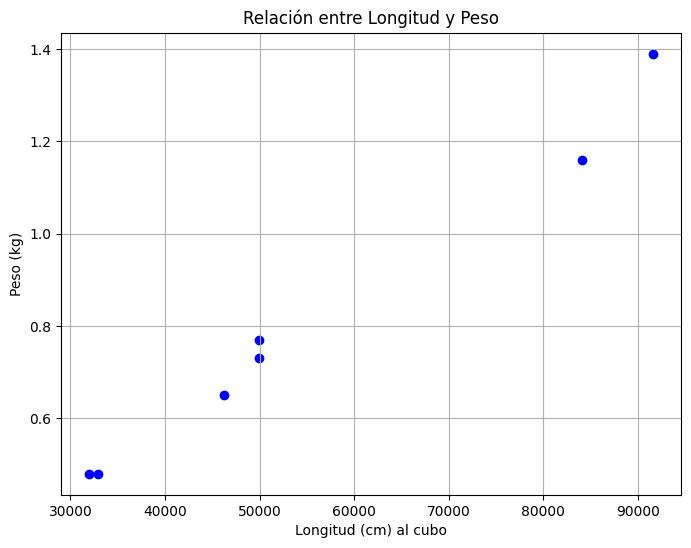

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Datos originales
longitud = np.array([36.83, 31.75, 43.815, 36.83, 32.06, 45.08, 35.88])
peso = np.array([0.77, 0.48, 1.16, 0.73, 0.48, 1.39, 0.65])

# Elevar cada elemento de longitud al cubo
longitud_3 = np.power(longitud, 3)

# Crear el gráfico de dispersión
plt.figure(figsize=(8, 6))
plt.scatter(longitud_3, peso, color='blue', marker='o')

# Agregar títulos y etiquetas
plt.title('Relación entre Longitud y Peso')
plt.xlabel('Longitud (cm) al cubo')
plt.ylabel('Peso (kg)')
plt.grid(True)
plt.show()



* Utiliza los datos anteriores y el método de tu preferencia para estimar un buen valor de $K$ para nuestro modelo de similitud geométrica $ W = Kl*3 $

La pendiente es 0.0000
La ordenada al origen es 0.0072
El coeficiente de correlación es 0.9931


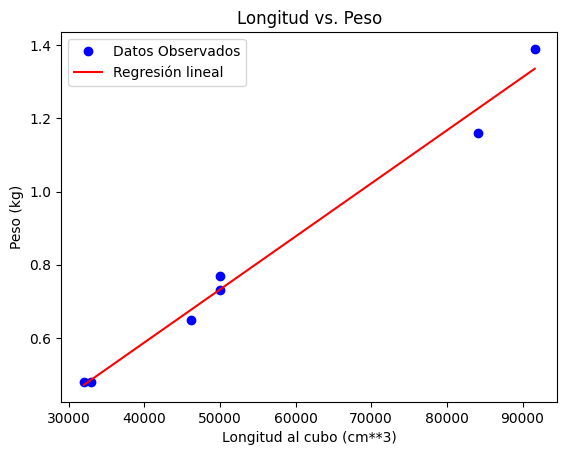

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Función para calcular los parámetros de regresión
def ParametrosRegresion(x, y):
    N = len(x)  # Número de datos
    ΣX = np.sum(x)
    ΣY = np.sum(y)
    ΣXX = np.sum(x**2)
    ΣXY = np.sum(x * y)
    ΣYY = np.sum(y**2)

    # Ecuaciones para el metodo de mínimos cuadrados y correlación lineal
    m = ((N * ΣXY) - (ΣX * ΣY)) / ((N * ΣXX) - (ΣX**2))
    b = (ΣY - m * ΣX) / N
    r = ((N * ΣXY) - (ΣX * ΣY)) / np.sqrt(((N * ΣXX) - (ΣX**2)) * ((N * ΣYY) - (ΣY**2)))

    return m, b, r

# Fórmula de la recta
def formula(m, b, x):
    return m * x + b

# Datos
longitud_3 = np.array([36.83, 31.75, 43.815, 36.83, 32.06, 45.08, 35.88])**3
peso = np.array([0.77, 0.48, 1.16, 0.73, 0.48, 1.39, 0.65])

# Ajuste con mínimos cuadrados
m, b, r = ParametrosRegresion(longitud_3, peso)

# Impresión de los resultados
print('La pendiente es {:.4f}'.format(m))
print('La ordenada al origen es {:.4f}'.format(b))
print('El coeficiente de correlación es {:.4f}'.format(r))

# Gráfica
x1 = np.linspace(min(longitud_3), max(longitud_3), 200)
y1 = formula(m, b, x1)

plt.plot(longitud_3, peso, 'bo', label="Datos Observados")
plt.plot(x1, y1, "r-", label="Regresión lineal")
plt.xlabel("Longitud al cubo (cm**3)")
plt.ylabel("Peso (kg)")
plt.legend()
plt.title("Longitud vs. Peso")
plt.show()



* Grafica la estimación contra los datos. ¿Qúe tan bueno es el
ajuste? ¿Hay algún efecto que nuestro modelo no capture? : **Dado que el coeficiente de coreelación es casi de 1 o cercano a 1, y la pendiente es 0, podemos decir que para nuestro análisis el ajuste fue bueno.**

Supongamos que además de los datos anteriores también tenemos disponible la circunferencia máxima
de cada pez.
* Realice el ajuste del nuevo modelo en términos de la circunferencia ¿Cómo queda la fórmula explicita del modelo?¿Qué tan bueno es el ajuste?
: **Lo que decidí aplicar en vez de una correlación lineal, fue un análisis de regresión múltiple. Por lo cual me base en las siguientes referencias, así como sugerencias de compañeros de semestres superiores: https://yuasaavedraco.github.io/Docs/Regresi%C3%B3n_Lineal_M%C3%BAltiple_con_Python.html y https://yuasaavedraco.github.io/Docs/Regresi%C3%B3n_Lineal_M%C3%BAltiple_con_Python.html**

|  LONGITUD (cm) | PESO (kg)| CIRCUNFERENCIA|
|-----------|-----------|-----------|
| 36.83   | 0.77   | 24.77   |
| 31.75  | 0.48   | 21.29   |
| 43.815  | 1.16   | 27.94   |
| 36.83  | 0.73   | 24.77   |
| 32.06  | 0.48   | 21.59   |
| 45.08  | 1.39  | 31.75  |
| 35.88  | 0.65  | 22.86  |
Tabla 2. Datos de Longitud, Peso y Circunferencia

== Primero, la fórmula del modelo en términos de la circunferencia $ C $ es:
$
\text{Peso} = m_{\text{circ}} \cdot C + b_{\text{circ}}
$
donde $ m_{\text{circ}} $ es la pendiente y $ b_{\text{circ}} $ la ordenada al origen


Modelo en función de la circunferencia y longitud al cubo:
La pendiente para la circunferencia es 0.0420
La pendiente para la longitud^3 es 0.0000
La ordenada al origen es -0.6847

Fórmula del modelo: Peso = 0.0420 * Circunferencia + 0.0000 * Longitud^3 + -0.6847


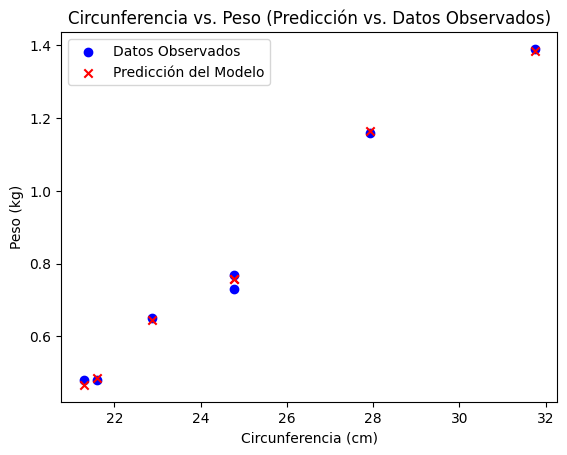

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Función de regresión múltiple
def regresion_multiple(X, Y):
    # Aplicamos el método de mínimos cuadrados como veniamos haciendo
    X_t = np.transpose(X)
    beta = np.linalg.inv(X_t @ X) @ X_t @ Y
    return beta #Nos servira para pasos posteriores del análisis

# Datos
longitud_3 = np.array([36.83, 31.75, 43.815, 36.83, 32.06, 45.08, 35.88])**3
circunferencia = np.array([24.77, 21.29, 27.94, 24.77, 21.59, 31.75, 22.86])
peso = np.array([0.77, 0.48, 1.16, 0.73, 0.48, 1.39, 0.65])

# Matriz de características (incluye una columna de 1s para el intercepto)
X = np.column_stack((np.ones(len(circunferencia)), circunferencia, longitud_3))

# Aplicamos la regresión múltiple a los datos de la función
beta = regresion_multiple(X, peso)

# Imprimimos los coeficientes
b = beta[0]
m_circ = beta[1]
m_long3 = beta[2]
print(f'Modelo en función de la circunferencia y longitud al cubo:')
print(f'La pendiente para la circunferencia es {m_circ:.4f}')
print(f'La pendiente para la longitud^3 es {m_long3:.4f}')
print(f'La ordenada al origen es {b:.4f}')

# Fórmula explícita del modelo
print(f'\nFórmula del modelo: Peso = {m_circ:.4f} * Circunferencia + {m_long3:.4f} * Longitud^3 + {b:.4f}')

# Predicciones basadas en el modelo
peso_pred = X @ beta

# Gráfica
plt.scatter(circunferencia, peso, color='blue', label='Datos Observados')
plt.scatter(circunferencia, peso_pred, color='red', label='Predicción del Modelo', marker='x')
plt.xlabel('Circunferencia (cm)')
plt.ylabel('Peso (kg)')
plt.legend()
plt.title('Circunferencia vs. Peso (Predicción vs. Datos Observados)')
plt.show()


### Fórmula del modelo

El modelo de regresión múltiple para predecir el peso en función de la circunferencia $ C $ y la longitud al cubo $ L^3 $ es:

$
\text{Peso} = m_1 \cdot C + m_2 \cdot L^3 + b
$

Donde:
- $ m_1 $ es la pendiente asociada a la circunferencia.
- $ m_2 $ es la pendiente asociada a la longitud al cubo.
- $ b $ es la ordenada al origen (intercepto).

Este modelo se obtiene mediante el ajuste por mínimos cuadrados, aunque con modificaciones que, a decir verdad, no me quedan muy claras al respecto

### Evaluación del ajuste

Para evaluar la bondad del ajuste, utilizamos el coeficiente de determinación $ R^2 $. Este coeficiente se calcula como:

$
R^2 = 1 - \frac{SS_{\text{res}}}{SS_{\text{tot}}}
$

Donde:
- $ SS_{\text{res}} $ es la suma de los residuos al cuadrado.
- $ SS_{\text{tot}} $ es la suma total de cuadrados.

Un valor de $ R^2 $ cercano a 1 indica un buen ajuste del modelo, es decir, que las variables predictoras explican bien la variabilidad en el peso de los peces.


In [ ]:
# Calcular el coeficiente de determinación R^2
def calcular_R2(Y_real, Y_pred):
    ss_res = np.sum((Y_real - Y_pred) ** 2)  # Suma de los residuos al cuadrado
    ss_tot = np.sum((Y_real - np.mean(Y_real)) ** 2)  # Suma total de cuadrados
    r2 = 1 - (ss_res / ss_tot)
    return r2

# Cálculo de R^2
r2 = calcular_R2(peso, peso_pred)
print(f"\nEl coeficiente de determinación R^2 es: {r2:.4f}")



El coeficiente de determinación R^2 es: 0.9983


**Por lo tanto, podemos decir que nuestro coeficiente R cuadrada de 0.9983 es ligeramente mejor que el de minimos cuadrados de 0.9931**

*Ejercicio 2:* El objetivo principal es dar una estrategia de negocio, durante temporada alta, a un hotel en Los Cabos de acuerdo a las observaciones de su gerente, utilizando modelos de teoría de control.
_________________________________________________________________________
**El hotel tiene 60 habitaciones, el costo diario de mantener una habitación es de 240 pesos, independientemente de si se renta o no. El gerente ha observado que, durante temporada alta, todas las habitaciones se ocupan si éstas se ofertan a 2,400 pesos; mientras que por cada 200 pesos de aumento en la renta, dos habitaciones se desocupan. ¿Cuánto debería cobrar el hotel por habitación durante temporada alta para maximizar las ganancias diarias?**
_________________________________________________________________________
* (a) Explica qué suposiciones estás tomando, define las variables que utilizarás y cuál es el objetivo del problema. Aclara cuáles son las unidades de cada variable y revisa que, en las ecuaciones que definas, las unidades de las variables sean congruentes.
* (b) Cómo cambiaría el objetivo si además, por cuestiones fiscales, el gerente desea que las ganancias diarias no sobrepasen los 15,000 pesos?

# Parte (a): Maximización de las ganancias


El precio óptimo para maximizar las ganancias es: 4199.95 pesos


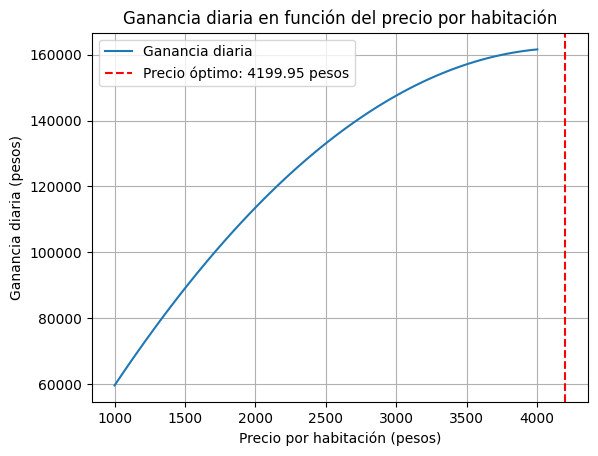

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
#Me apopyé de un forum en Stackoverflow: https://stackoverflow.com/questions/30135587/how-to-use-scipy-optimize-minimize

# Definimos las variables
N = 60        # Número total de habitaciones
Cm = 240      # Costo diario de mantenimiento por habitación
P_base = 2400 # Precio base por habitación

# Función para calcular el número de habitaciones ocupadas en función del precio 'p'
def ocupacion(p):
    return 60 - (p - 2400) / 100

# Escribimos la función de ganancia diaria
def ganancia(p):
    ingresos = p * ocupacion(p)
    costos = N * Cm
    return ingresos - costos

# Maximizamos la función de ganancia usando scipy.optimize.minimize (minimización de -ganancia)
resultado = minimize(lambda p: -ganancia(p), P_base, bounds=[(0, None)]) # Búsqueda dentro de límites positivos
precio_optimo = resultado.x[0]

# Imprimimos el resultado
print(f"El precio óptimo para maximizar las ganancias es: {precio_optimo:.2f} pesos")

# Graficamos la función de ganancia
p_vals = np.linspace(1000, 4000, 100)
g_vals = [ganancia(p) for p in p_vals]

plt.plot(p_vals, g_vals, label="Ganancia diaria")
plt.axvline(x=precio_optimo, color='r', linestyle='--', label=f'Precio óptimo: {precio_optimo:.2f} pesos')
plt.xlabel("Precio por habitación (pesos)")
plt.ylabel("Ganancia diaria (pesos)")
plt.title("Ganancia diaria en función del precio por habitación")
plt.legend()
plt.grid(True)
plt.show()


# Parte (b): Restricción de ganancias diarias no mayores a 15,000 pesos


El precio óptimo bajo la restricción de 15,000 pesos de ganancia es: 4200.09 pesos


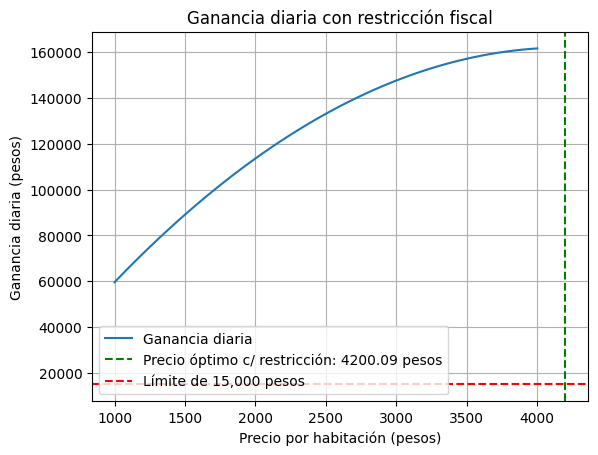

In [ ]:
# Restricción de que las ganancias no sobrepasen los 15,000 pesos
def restriccion(p):
    return ganancia(p) - 15000

# Maximizamos de nuevo con la restricción
resultado_restriccion = minimize(lambda p: -ganancia(p), P_base, bounds=[(0, None)], constraints={'type': 'ineq', 'fun': restriccion})
precio_optimo_con_restriccion = resultado_restriccion.x[0]

# Imprimimos el resultado
print(f"El precio óptimo bajo la restricción de 15,000 pesos de ganancia es: {precio_optimo_con_restriccion:.2f} pesos")

# Graficamos con la restricción
plt.plot(p_vals, g_vals, label="Ganancia diaria")
plt.axvline(x=precio_optimo_con_restriccion, color='g', linestyle='--', label=f'Precio óptimo c/ restricción: {precio_optimo_con_restriccion:.2f} pesos')
plt.axhline(y=15000, color='r', linestyle='--', label='Límite de 15,000 pesos')
plt.xlabel("Precio por habitación (pesos)")
plt.ylabel("Ganancia diaria (pesos)")
plt.title("Ganancia diaria con restricción fiscal")
plt.legend()
plt.grid(True)
plt.show()


En esta última parte, me sentí muy perdido respecto al tipo de análisis que estuve haciendo, asi que recurrí neta y enteramente a la ayuda de mi equipo de la asignatura